# **1- INSTALL THE LIBRARIES**

In [20]:
!pip install textstat pdfplumber nltk pandas

# **2- IMPORT EVERYTHING**

In [21]:
import pdfplumber
import nltk
import pandas as pd
import textstat

from nltk.tokenize import sent_tokenize, word_tokenize

# **3- DOWNLOAD THE TOKENIZER**

In [22]:

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# **4- UPLOAD PDFS**

In [23]:
from google.colab import files
uploaded = files.upload()

Saving A1.txt to A1 (1).txt
Saving A2.txt to A2 (1).txt
Saving B1.txt to B1 (1).txt
Saving B2.txt to B2 (1).txt
Saving C1.txt to C1 (1).txt


# **5- READING ONE UPLOADED FILE INTO PYTHON:**

In [24]:
with open('A1.txt', 'r', encoding='utf-8') as file:
    a1_text = file.read()

print("Number of characters:", len(a1_text))
print(a1_text[:300])

Number of characters: 4579
Early in the morning in the USA, a baby opened his eyes and looked at his mother. “Isn't he pretty?” she asked the camera. Around the world, people got up, and washed, and had breakfast. A 15-year-old boy shaved for the first time. He didn’t enjoy it! A boy kissed his mother on her birthday.

The 24


# **6- READING ALL FILES AND TAGGING EACH WITH CEFR LEVEL**

In [25]:
filenames = ['A1.txt', 'A2.txt', 'B1.txt', 'B2.txt', 'C1.txt']
passages = {}

for name in filenames:
    level = name.replace('.txt', '')
    with open(name, 'r', encoding='utf-8') as file:
        passages[level] = file.read()

for level, text in passages.items():
    print(level, "-", len(text), "characters")

A1 - 4579 characters
A2 - 4673 characters
B1 - 5899 characters
B2 - 4484 characters
C1 - 5234 characters


# **4- TEXT NORMALIZATION:**

In [26]:
def normalize_quotes(text):
    replacements = {'’': "'", '‘': "'", '“': '"', '”': '"'}
    for old_char, new_char in replacements.items():
        text = text.replace(old_char, new_char)
    return text

normalized_passages = {level: normalize_quotes(text) for level, text in passages.items()}

print(passages['A1'][:200])
print("---")
print(normalized_passages['A1'][:200])

Early in the morning in the USA, a baby opened his eyes and looked at his mother. “Isn't he pretty?” she asked the camera. Around the world, people got up, and washed, and had breakfast. A 15-year-old
---
Early in the morning in the USA, a baby opened his eyes and looked at his mother. "Isn't he pretty?" she asked the camera. Around the world, people got up, and washed, and had breakfast. A 15-year-old


# **5- TOKENIZING A PASSAGE INTO WORDS AND SENTENCES:**

In [27]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [28]:
from nltk.tokenize import word_tokenize, sent_tokenize

a1_words = word_tokenize(normalized_passages['A1'])
a1_sentences = sent_tokenize(normalized_passages['A1'])

print("Number of words:", len(a1_words))
print("Number of sentences:", len(a1_sentences))
print(a1_words[:20])
print(a1_sentences[:2])

Number of words: 1108
Number of sentences: 133
['Early', 'in', 'the', 'morning', 'in', 'the', 'USA', ',', 'a', 'baby', 'opened', 'his', 'eyes', 'and', 'looked', 'at', 'his', 'mother', '.', '``']
['Early in the morning in the USA, a baby opened his eyes and looked at his mother.', '"Isn\'t he pretty?"']


In [29]:
results = []

for level, text in normalized_passages.items():
    words = word_tokenize(text)
    sentences = sent_tokenize(text)
    results.append({
        'level': level,
        'word_count': len(words),
        'sentence_count': len(sentences)
    })

for r in results:
    print(r)

{'level': 'A1', 'word_count': 1108, 'sentence_count': 133}
{'level': 'A2', 'word_count': 1031, 'sentence_count': 82}
{'level': 'B1', 'word_count': 1272, 'sentence_count': 81}
{'level': 'B2', 'word_count': 926, 'sentence_count': 51}
{'level': 'C1', 'word_count': 981, 'sentence_count': 42}


# **6- RUNNING THE READABILITY FORMULAS:**

In [30]:
import textstat

text = normalized_passages['A1']

print("Flesch Reading Ease:", textstat.flesch_reading_ease(text))
print("Flesch-Kincaid Grade:", textstat.flesch_kincaid_grade(text))
print("SMOG Index:", textstat.smog_index(text))
print("Dale-Chall Score:", textstat.dale_chall_readability_score(text))
print("Coleman-Liau Index:", textstat.coleman_liau_index(text))
print("Automated Readability Index:", textstat.automated_readability_index(text))
print("Gunning Fog Index:", textstat.gunning_fog(text))
print("Linsear Write Formula:", textstat.linsear_write_formula(text))

Flesch Reading Ease: 85.7541401037806
Flesch-Kincaid Grade: 3.1550185322461104
SMOG Index: 6.950104931194217
Dale-Chall Score: 7.54697173214727
Coleman-Liau Index: 3.4802816901408455
Automated Readability Index: 2.5956491228070178
Gunning Fog Index: 4.820459599703485
Linsear Write Formula: 3.909090909090909


In [31]:
formula_results = []

for level, text in normalized_passages.items():
    formula_results.append({
        'level': level,
        'flesch_reading_ease': textstat.flesch_reading_ease(text),
        'flesch_kincaid_grade': textstat.flesch_kincaid_grade(text),
        'smog_index': textstat.smog_index(text),
        'dale_chall_score': textstat.dale_chall_readability_score(text),
        'coleman_liau_index': textstat.coleman_liau_index(text),
        'automated_readability_index': textstat.automated_readability_index(text),
        'gunning_fog': textstat.gunning_fog(text),
        'linsear_write': textstat.linsear_write_formula(text)
    })

for r in formula_results:
    print(r)

{'level': 'A1', 'flesch_reading_ease': 85.7541401037806, 'flesch_kincaid_grade': 3.1550185322461104, 'smog_index': 6.950104931194217, 'dale_chall_score': 7.54697173214727, 'coleman_liau_index': 3.4802816901408455, 'automated_readability_index': 2.5956491228070178, 'gunning_fog': 4.820459599703485, 'linsear_write': 3.909090909090909}
{'level': 'A2', 'flesch_reading_ease': 78.2134216790194, 'flesch_kincaid_grade': 5.073516391106043, 'smog_index': 8.510919360123488, 'dale_chall_score': 7.403056419612315, 'coleman_liau_index': 5.453819840364883, 'automated_readability_index': 4.30425, 'gunning_fog': 6.665501710376283, 'linsear_write': 3.230769230769231}
{'level': 'B1', 'flesch_reading_ease': 76.67763044225484, 'flesch_kincaid_grade': 5.95227302933089, 'smog_index': 9.086538512062042, 'dale_chall_score': 8.177200476626947, 'coleman_liau_index': 6.457561869844181, 'automated_readability_index': 6.0224212328767095, 'gunning_fog': 8.241434463794684, 'linsear_write': 4.5}
{'level': 'B2', 'flesc

# **7- BUILDING THE RESULTS TABLE:**

In [32]:
df = pd.DataFrame(formula_results)
df

,level,flesch_reading_ease,flesch_kincaid_grade,smog_index,dale_chall_score,coleman_liau_index,automated_readability_index,gunning_fog,linsear_write
0,A1,85.754140,3.155019,6.950105,7.546972,3.480282,2.595649,4.820460,3.909091
1,A2,78.213422,5.073516,8.510919,7.403056,5.453820,4.304250,6.665502,3.230769
2,B1,76.677630,5.952273,9.086539,8.177200,6.457562,6.022421,8.241434,4.500000
3,B2,69.813604,7.451861,10.355216,9.092297,8.322630,8.396646,9.766685,8.833333
4,C1,49.478974,11.338116,13.062145,9.594949,11.185151,12.361059,13.355032,8.142857


# **9-SORTING THE TABLE INTO PROPER CEFR ORDER:**

In [33]:
level_order = ['A1', 'A2', 'B1', 'B2', 'C1']
df['level'] = pd.Categorical(df['level'], categories=level_order, ordered=True)
df = df.sort_values('level').reset_index(drop=True)
df

,level,flesch_reading_ease,flesch_kincaid_grade,smog_index,dale_chall_score,coleman_liau_index,automated_readability_index,gunning_fog,linsear_write
0,A1,85.754140,3.155019,6.950105,7.546972,3.480282,2.595649,4.820460,3.909091
1,A2,78.213422,5.073516,8.510919,7.403056,5.453820,4.304250,6.665502,3.230769
2,B1,76.677630,5.952273,9.086539,8.177200,6.457562,6.022421,8.241434,4.500000
3,B2,69.813604,7.451861,10.355216,9.092297,8.322630,8.396646,9.766685,8.833333
4,C1,49.478974,11.338116,13.062145,9.594949,11.185151,12.361059,13.355032,8.142857


# **10- MATPLOTLIB CHARTS:**

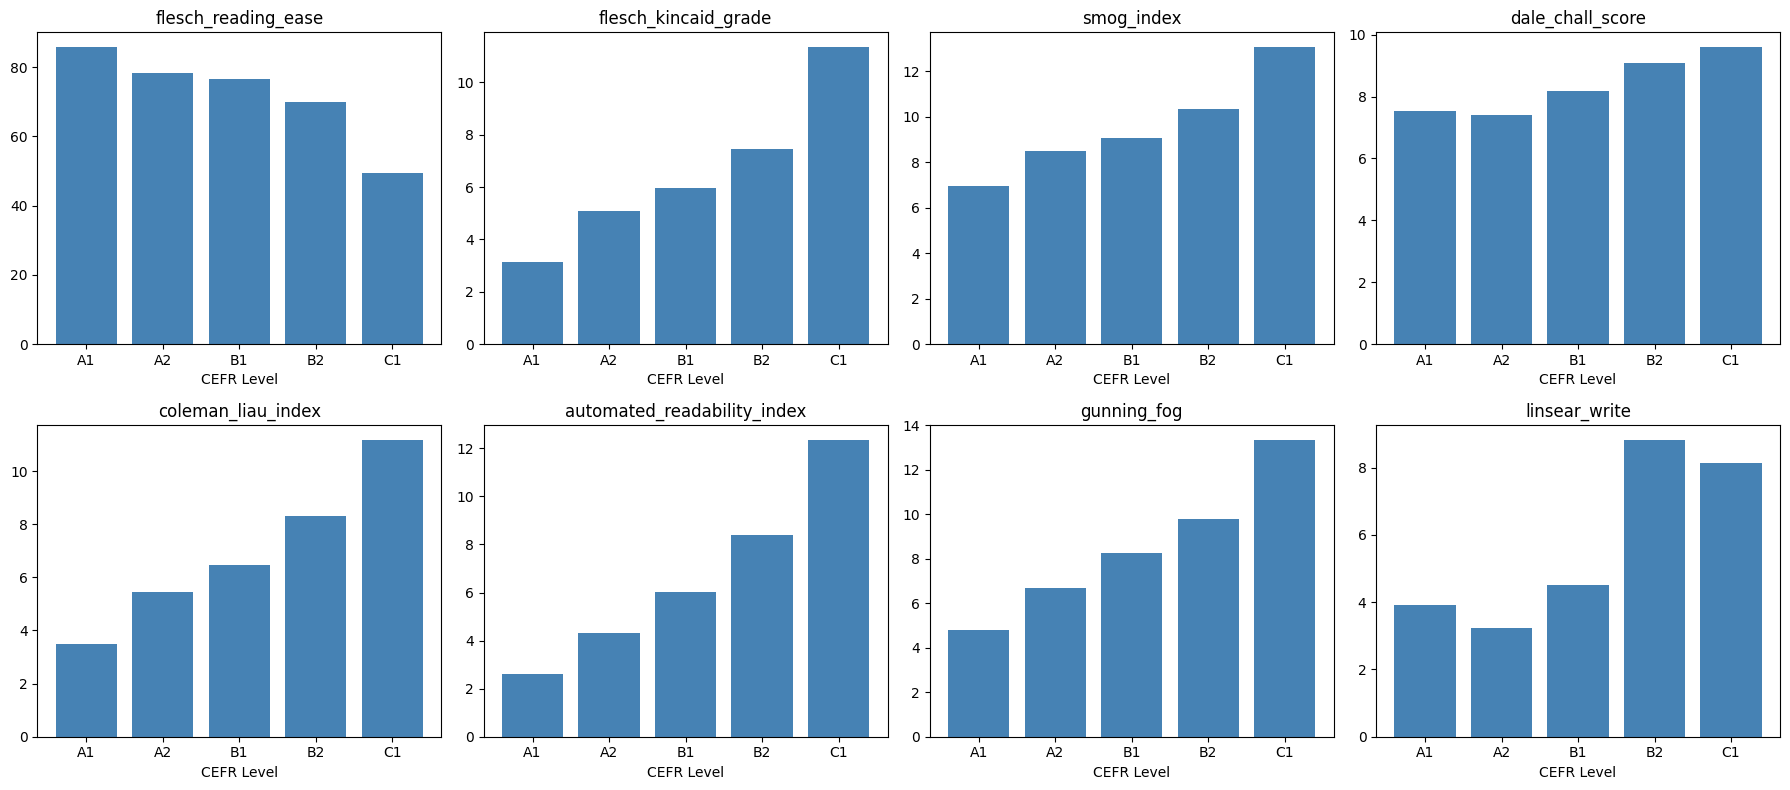

In [34]:
formula_columns = ['flesch_reading_ease', 'flesch_kincaid_grade', 'smog_index',
                    'dale_chall_score', 'coleman_liau_index', 'automated_readability_index',
                    'gunning_fog', 'linsear_write']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(formula_columns):
    axes[i].bar(df['level'], df[col], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('CEFR Level')

plt.tight_layout()
plt.show()

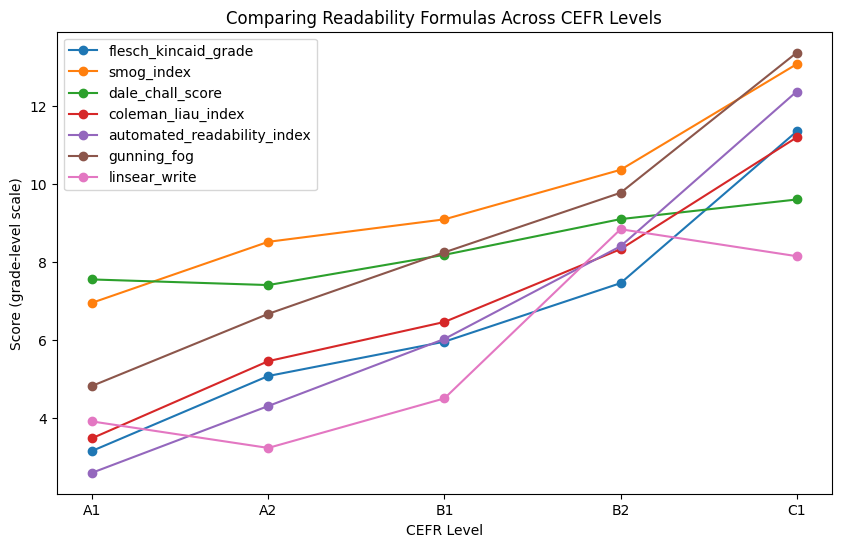

In [35]:
comparison_columns = ['flesch_kincaid_grade', 'smog_index', 'dale_chall_score',
                       'coleman_liau_index', 'automated_readability_index',
                       'gunning_fog', 'linsear_write']

plt.figure(figsize=(10, 6))

for col in comparison_columns:
    plt.plot(df['level'], df[col], marker='o', label=col)

plt.xlabel('CEFR Level')
plt.ylabel('Score (grade-level scale)')
plt.title('Comparing Readability Formulas Across CEFR Levels')
plt.legend()
plt.show()